<a href="https://colab.research.google.com/github/Shariyakhan07/Water-Quality-Prediction-Using-Machine-Learning/blob/main/ShariyaSBCA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Logistic Regression

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("water_quality_dataset.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,6.577,139.941,35298.511,8.335,NaN,395.217,NaN,67.707,4.572,1
1,7.226,206.214,42738.215,4.885,362.197,400.260,9.975,92.892,3.748,0
2,8.162,145.402,8845.815,5.883,332.483,626.436,15.269,82.528,3.473,0
3,7.643,201.883,NaN,5.524,366.515,437.718,6.727,69.507,4.424,1
4,6.869,199.384,12493.303,7.089,303.288,395.393,13.965,96.822,3.550,1


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1700
Columns: 10


In [4]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
ph,83
Hardness,53
Solids,65
Chloramines,81
Sulfate,71
Conductivity,57
Organic_carbon,70
Trihalomethanes,55
Turbidity,72
Potability,0


In [6]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 1673


In [7]:
numeric_columns = df.select_dtypes(
    include=np.number).columns

for column in numeric_columns:
    if column != "Potability":
        df[column] = df[column].fillna(
            df[column].median())
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [8]:
X = df.drop("Potability", axis=1)
y = df["Potability"]
print("Features:", X.shape)
print("Target:", y.shape)

Features: (1673, 9)
Target: (1673,)


In [9]:
print(y.value_counts())

Potability
1    1217
0     456
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1338, 9)
Testing data: (335, 9)


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = LogisticRegression(
    max_iter=1000,random_state=42)

In [13]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [14]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(
    X_test)[:, 1]
print(y_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


In [15]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7194029850746269


In [16]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.7314814814814815


In [17]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9713114754098361


In [18]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8345070422535211


In [19]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_probability)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.5669699153305711


In [20]:
print("Logistic Regression Results")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Logistic Regression Results
--------------------------
Accuracy : 0.7194029850746269
Precision: 0.7314814814814815
Recall   : 0.9713114754098361
F1 Score : 0.8345070422535211
ROC-AUC  : 0.5669699153305711


In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[  4  87]
 [  7 237]]


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.36      0.04      0.08        91
           1       0.73      0.97      0.83       244

    accuracy                           0.72       335
   macro avg       0.55      0.51      0.46       335
weighted avg       0.63      0.72      0.63       335



In [23]:
sample = np.array([[7.0,190,22000,7.0,330,420,14,65,3.8]])
sample_scaled = scaler.transform(sample)
prediction = model.predict(
    sample_scaled)
probability = model.predict_proba(
    sample_scaled)[0][1]
if prediction[0] == 1:
    print("Water Quality: POTABLE")
else:
    print("Water Quality: NOT POTABLE")
print(
    "Potability Probability:",
    round(probability, 3))

Water Quality: POTABLE
Potability Probability: 0.755


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
import joblib
joblib.dump(model,
    "logistic_regression_model.pkl")
joblib.dump(scaler,"water_quality_scaler.pkl")
print("Model saved successfully")

Model saved successfully


Decision Tree.

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
random_forest = RandomForestClassifier(
    n_estimators=100,random_state=42)

In [27]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
rf_pred = random_forest.predict(X_test)
rf_probability = random_forest.predict_proba(X_test)[:, 1]

In [29]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7194029850746269


In [30]:
rf_recall = recall_score(y_test, rf_pred)
print("Random Forest Recall:", rf_recall)

Random Forest Recall: 0.9016393442622951


In [31]:
rf_f1 = f1_score(y_test, rf_pred)
print("Random Forest F1 Score:", rf_f1)

Random Forest F1 Score: 0.8239700374531835


In [32]:
rf_roc_auc = roc_auc_score(y_test, rf_probability)
print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.676860025220681


In [33]:
from sklearn.metrics import precision_score

rf_precision = precision_score(y_test, rf_pred)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
--------------------
Accuracy : 0.7194029850746269
Precision: 0.7586206896551724
Recall   : 0.9016393442622951
F1 Score : 0.8239700374531835
ROC-AUC  : 0.676860025220681


In [34]:
rf_cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:")
print(rf_cm)

Confusion Matrix:
[[ 21  70]
 [ 24 220]]


In [35]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.47      0.23      0.31        91
           1       0.76      0.90      0.82       244

    accuracy                           0.72       335
   macro avg       0.61      0.57      0.57       335
weighted avg       0.68      0.72      0.68       335



In [36]:
rf_importance = pd.DataFrame({"Feature": X.columns,
    "Importance": random_forest.feature_importances_})
rf_importance = rf_importance.sort_values(
    "Importance", ascending=False)
print(rf_importance)

           Feature  Importance
0               ph    0.147401
2           Solids    0.127335
7  Trihalomethanes    0.118895
5     Conductivity    0.108928
8        Turbidity    0.106188
3      Chloramines    0.101115
4          Sulfate    0.099941
1         Hardness    0.098495
6   Organic_carbon    0.091703


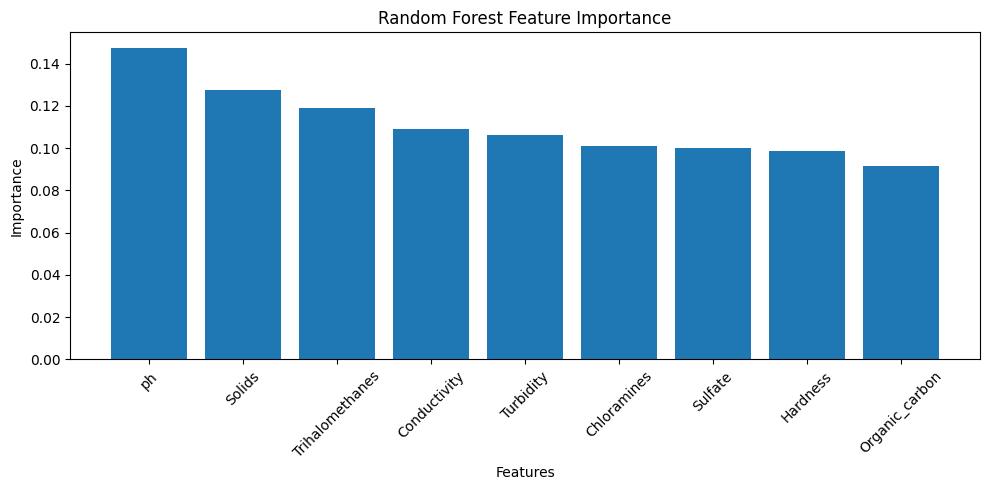

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(rf_importance["Feature"], rf_importance["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [38]:
sample = np.array([[7.0, 190, 22000, 7.0, 330, 420, 14, 65, 3.8]])
prediction = random_forest.predict(sample)
probability = random_forest.predict_proba(sample)[0][1]
if prediction[0] == 1:
    print("Water Quality: POTABLE")
else:
    print("Water Quality: NOT POTABLE")
print("Potability Probability:", round(probability, 3))

Water Quality: NOT POTABLE
Potability Probability: 0.36


In [39]:
import joblib
joblib.dump(random_forest, "random_forest_model.pkl")
print("Random Forest model saved successfully")

Random Forest model saved successfully
